# Notebook 10 - OU coupling and Levy recovery

This notebook mirrors the global constant-lambda workflow of notebook 08 for the
OU / CARMA(1,0) benchmark. The OU marginal coefficients are the benchmark
estimates reported in notebooks 06 and 07.

Notation:

- `kappa_T`, `kappa_X`: OU mean-reversion rates, with state dynamics
  `dY = -kappa Y dt + ...`
- `sigma_T`, `sigma_X`: marginal OU diffusion scales from the Yuima fits
- `lambda_hat`: structural coupling from the temperature driver into the price
  state equation


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.stats import norm, norminvgauss, poisson, pearsonr, spearmanr
from statsmodels.stats.diagnostic import acorr_ljungbox

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

DATA_DIR = Path("../data")
LEVY_DIR = DATA_DIR / "levy"
KALMAN_DIR = DATA_DIR / "kalman"
LEVY_DIR.mkdir(parents=True, exist_ok=True)
KALMAN_DIR.mkdir(parents=True, exist_ok=True)

# Copied from the OU / CARMA(1,0) benchmark cells of notebooks 06 and 07.
# Yuima was run with h = 1 on hourly residual observations.
OU_PARAMS = pd.DataFrame(
    {
        "series": ["temperature", "price"],
        "kappa": [0.0143769, 0.0790154],
        "b0": [1.0, 1.0],
        "sigma": [0.64279, 0.0133445],
        "source_notebook": ["06temp_yuima.ipynb", "07price_yuima.ipynb"],
    }
).set_index("series")

kappa_T = float(OU_PARAMS.loc["temperature", "kappa"])
kappa_X = float(OU_PARAMS.loc["price", "kappa"])
b_T = float(OU_PARAMS.loc["temperature", "b0"])
b_X = float(OU_PARAMS.loc["price", "b0"])
sigma_T = float(OU_PARAMS.loc["temperature", "sigma"])
sigma_X_marginal = float(OU_PARAMS.loc["price", "sigma"])

display(OU_PARAMS)

OU_PARAMS.reset_index().to_csv(KALMAN_DIR / "ou_carma10_params.csv", index=False)


,kappa,b0,sigma,source_notebook
series,,,,
temperature,0.014377,1.0,0.642790,06temp_yuima.ipynb
price,0.079015,1.0,0.013345,07price_yuima.ipynb


In [2]:
def read_residual_series(path, value_col):
    df = pd.read_csv(path, parse_dates=["datetime"])
    df["datetime"] = pd.to_datetime(df["datetime"], utc=True)
    df = df[["datetime", value_col]].dropna().sort_values("datetime")
    df = df.set_index("datetime")
    df[value_col] = df[value_col].astype(float)
    return df


def interval_hours(index):
    index = pd.DatetimeIndex(index)
    return ((index[1:] - index[:-1]) / pd.Timedelta(hours=1)).to_numpy(dtype=float)


def ou_transition(kappa, dt):
    return np.exp(-float(kappa) * np.asarray(dt, dtype=float))


def ou_variance_kernel(kappa, sigma, dt):
    dt = np.asarray(dt, dtype=float)
    kappa = float(kappa)
    sigma = float(sigma)
    if abs(kappa) < 1e-14:
        return sigma**2 * dt
    return sigma**2 * (1.0 - np.exp(-2.0 * kappa * dt)) / (2.0 * kappa)


def ou_cross_kernel(kappa_t, kappa_x, sigma_t, dt):
    dt = np.asarray(dt, dtype=float)
    rate_sum = float(kappa_t) + float(kappa_x)
    sigma_t = float(sigma_t)
    if abs(rate_sum) < 1e-14:
        return sigma_t**2 * dt
    return sigma_t**2 * (1.0 - np.exp(-rate_sum * dt)) / rate_sum


def ou_state_residuals(y, index, kappa):
    y = np.asarray(y, dtype=float)
    dt = interval_hours(index)
    F = ou_transition(kappa, dt)
    residual = y[1:] - F * y[:-1]
    return residual, dt, F, pd.DatetimeIndex(index[1:])


def recover_ou_driver_increments(y, index, kappa, sigma):
    y = np.asarray(y, dtype=float)
    dt = interval_hours(index)
    drift_integral = 0.5 * (y[:-1] + y[1:]) * dt
    dL = (np.diff(y) + float(kappa) * drift_integral) / float(sigma)
    return pd.Series(dL, index=pd.DatetimeIndex(index[1:]), name="dL")


def centered_covariance(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    return float(np.mean((x - x.mean()) * (y - y.mean())))


def safe_pearson_r(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) < 3 or np.std(x, ddof=1) == 0 or np.std(y, ddof=1) == 0:
        return np.nan
    return float(pearsonr(x, y).statistic)


def safe_spearman_r(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) < 3 or np.std(x, ddof=1) == 0 or np.std(y, ddof=1) == 0:
        return np.nan
    return float(spearmanr(x, y).statistic)


def save_increment_series(series, path):
    out = pd.DataFrame(
        {
            "datetime": pd.DatetimeIndex(series.index).strftime("%Y-%m-%d %H:%M:%S"),
            "dL": series.to_numpy(dtype=float),
        }
    )
    out.to_csv(path, index=False)


In [3]:
temp_df = read_residual_series(DATA_DIR / "deseasonalised" / "temp_resid.csv", "temp_deseasoned")
price_df = read_residual_series(DATA_DIR / "deseasonalised" / "price_resid.csv", "price_deseasoned")

# Marginal OU fits have no intercept. Work with zero-mean residuals, as in 08.
temp_mean = float(temp_df["temp_deseasoned"].mean())
price_mean = float(price_df["price_deseasoned"].mean())
temp_df["T"] = temp_df["temp_deseasoned"] - temp_mean
price_df["X"] = price_df["price_deseasoned"] - price_mean

time_T = temp_df.index
time_X = price_df.index
y_T = temp_df["T"].to_numpy(float)
y_X = price_df["X"].to_numpy(float)

common_idx = time_T.intersection(time_X).sort_values()
y_T_c = temp_df.loc[common_idx, "T"].to_numpy(float)
y_X_c = price_df.loc[common_idx, "X"].to_numpy(float)

dL_T_full = recover_ou_driver_increments(y_T, time_T, kappa_T, sigma_T)
dL_X_full = recover_ou_driver_increments(y_X, time_X, kappa_X, sigma_X_marginal)

common_inc_idx = dL_T_full.index.intersection(dL_X_full.index).sort_values()
dL_T_s = dL_T_full.loc[common_inc_idx]
dL_X_s = dL_X_full.loc[common_inc_idx]
dL_T = dL_T_s.to_numpy(float)
dL_X = dL_X_s.to_numpy(float)

save_increment_series(dL_T_full, LEVY_DIR / "ou_temp_levy_increments.csv")
save_increment_series(dL_X_full, LEVY_DIR / "ou_price_levy_increments.csv")

alignment = pd.DataFrame(
    {
        "n": [len(y_T), len(y_X), len(common_idx), len(dL_T_full), len(dL_X_full), len(common_inc_idx)],
        "start": [
            time_T.min(),
            time_X.min(),
            common_idx.min(),
            dL_T_full.index.min(),
            dL_X_full.index.min(),
            common_inc_idx.min(),
        ],
        "end": [
            time_T.max(),
            time_X.max(),
            common_idx.max(),
            dL_T_full.index.max(),
            dL_X_full.index.max(),
            common_inc_idx.max(),
        ],
        "mean_removed": [temp_mean, price_mean, np.nan, np.nan, np.nan, np.nan],
    },
    index=[
        "temperature_residuals",
        "price_residuals",
        "joint_observations",
        "temperature_ou_increments_full",
        "price_ou_increments_full",
        "aligned_ou_increments",
    ],
)

increment_moments = pd.DataFrame(
    {
        "mean": [dL_T.mean(), dL_X.mean()],
        "std": [dL_T.std(ddof=1), dL_X.std(ddof=1)],
        "skew": [pd.Series(dL_T).skew(), pd.Series(dL_X).skew()],
        "kurtosis": [pd.Series(dL_T).kurtosis() + 3, pd.Series(dL_X).kurtosis() + 3],
    },
    index=["dL_T_ou", "dL_X_ou"],
)

display(alignment)
display(increment_moments.round(8))


,n,start,end,mean_removed
temperature_residuals,52608,2020-01-01 00:00:00+00:00,2025-12-31 23:00:00+00:00,6.513169e-10
price_residuals,26281,2023-01-01 00:00:00+00:00,2025-12-31 00:00:00+00:00,2.072228e-05
joint_observations,26281,2023-01-01 00:00:00+00:00,2025-12-31 00:00:00+00:00,NaN
temperature_ou_increments_full,52607,2020-01-01 01:00:00+00:00,2025-12-31 23:00:00+00:00,NaN
price_ou_increments_full,26280,2023-01-01 01:00:00+00:00,2025-12-31 00:00:00+00:00,NaN
aligned_ou_increments,26280,2023-01-01 01:00:00+00:00,2025-12-31 00:00:00+00:00,NaN


,mean,std,skew,kurtosis
dL_T_ou,0.002684,0.967177,-0.886066,9.748307
dL_X_ou,0.000101,0.995163,0.427679,84.929565


## OU driver distribution fits

The recovered OU driver increments use the CARMA(1,0) version of the same
Brockwell-style inversion used in notebooks 06 and 07:

`dL_k = (Y_k - Y_{k-1} + kappa * int_{k-1}^k Y_s ds) / sigma`,

with the integral approximated by the trapezoid rule on the hourly grid.


In [4]:
def fit_gaussian_nig(x, series_name):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    n = len(x)

    mu_g, sigma_g = norm.fit(x)
    ll_g = float(norm.logpdf(x, mu_g, sigma_g).sum())
    fit_rows = [
        {
            "series": series_name,
            "model": "Gaussian",
            "loglik": ll_g,
            "n_params": 2,
            "AIC": -2.0 * ll_g + 2.0 * 2,
            "BIC": -2.0 * ll_g + 2.0 * np.log(n),
        }
    ]
    param_rows = [
        {"series": series_name, "model": "Gaussian", "parameter": "mu", "value": mu_g},
        {"series": series_name, "model": "Gaussian", "parameter": "sigma", "value": sigma_g},
    ]

    try:
        a, b, loc, scale = norminvgauss.fit(x, method="MLE")
        ll_nig = float(norminvgauss.logpdf(x, a, b, loc=loc, scale=scale).sum())
        alpha = a / scale
        beta = b / scale
        delta = scale
        fit_rows.append(
            {
                "series": series_name,
                "model": "NIG",
                "loglik": ll_nig,
                "n_params": 4,
                "AIC": -2.0 * ll_nig + 2.0 * 4,
                "BIC": -2.0 * ll_nig + 4.0 * np.log(n),
            }
        )
        for parameter, value in [
            ("scipy_a", a),
            ("scipy_b", b),
            ("loc", loc),
            ("scale", scale),
            ("alpha", alpha),
            ("beta", beta),
            ("delta", delta),
            ("mu", loc),
        ]:
            param_rows.append(
                {"series": series_name, "model": "NIG", "parameter": parameter, "value": value}
            )
    except Exception:
        pass

    moments = {
        "series": series_name,
        "n": n,
        "mean": float(np.mean(x)),
        "std": float(np.std(x, ddof=1)),
        "skew": float(pd.Series(x).skew()),
        "kurtosis": float(pd.Series(x).kurtosis() + 3),
    }
    return pd.DataFrame(fit_rows), pd.DataFrame(param_rows), moments


def merton_pdf(x, sigma_diffusion, jump_intensity, jump_mean, jump_sigma, dt=1.0, max_jumps=20):
    x = np.asarray(x, dtype=float)
    density = np.zeros_like(x, dtype=float)
    for k in range(max_jumps + 1):
        weight = poisson.pmf(k, jump_intensity * dt)
        variance = sigma_diffusion**2 * dt + k * jump_sigma**2
        sd = np.sqrt(max(variance, 1e-14))
        density += weight * norm.pdf(x, loc=k * jump_mean, scale=sd)
    return np.maximum(density, 1e-300)


def fit_merton_threshold(x, series_name, dt=1.0, threshold_mult=3.0):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    n = len(x)
    robust_sigma = np.median(np.abs(x - np.median(x))) / 0.6745
    threshold = threshold_mult * robust_sigma
    is_jump = np.abs(x) > threshold
    jumps = x[is_jump]
    non_jumps = x[~is_jump]

    sigma_diffusion = float(np.std(non_jumps, ddof=1)) if len(non_jumps) > 1 else 0.0
    jump_intensity = float(np.sum(is_jump) / (n * dt))
    jump_mean = float(np.mean(jumps)) if len(jumps) else 0.0
    jump_sigma = float(np.std(jumps, ddof=1)) if len(jumps) > 1 else 0.0
    ll = float(np.log(merton_pdf(x, sigma_diffusion, jump_intensity, jump_mean, jump_sigma, dt)).sum())

    fit = pd.DataFrame(
        [
            {
                "series": series_name,
                "model": "Merton_threshold",
                "loglik": ll,
                "n_params": 4,
                "AIC": -2.0 * ll + 2.0 * 4,
                "BIC": -2.0 * ll + 4.0 * np.log(n),
            }
        ]
    )
    params = pd.DataFrame(
        [
            {"series": series_name, "model": "Merton_threshold", "parameter": "sigma_diffusion", "value": sigma_diffusion},
            {"series": series_name, "model": "Merton_threshold", "parameter": "jump_intensity", "value": jump_intensity},
            {"series": series_name, "model": "Merton_threshold", "parameter": "jump_mean", "value": jump_mean},
            {"series": series_name, "model": "Merton_threshold", "parameter": "jump_sigma", "value": jump_sigma},
            {"series": series_name, "model": "Merton_threshold", "parameter": "jump_threshold", "value": threshold},
            {"series": series_name, "model": "Merton_threshold", "parameter": "n_jumps", "value": float(np.sum(is_jump))},
        ]
    )
    return fit, params, is_jump


fit_T, params_T_fit, moments_T = fit_gaussian_nig(dL_T, "temperature_ou_driver")
fit_X, params_X_fit, moments_X = fit_gaussian_nig(dL_X, "price_ou_driver")
merton_fit_X, merton_params_X, price_jump_mask = fit_merton_threshold(dL_X, "price_ou_driver")

driver_fit = pd.concat([fit_T, fit_X, merton_fit_X], ignore_index=True)
driver_fit["delta_AIC"] = driver_fit["AIC"] - driver_fit.groupby("series")["AIC"].transform("min")
driver_params = pd.concat([params_T_fit, params_X_fit, merton_params_X], ignore_index=True)
driver_moments = pd.DataFrame([moments_T, moments_X])

display(driver_fit.round(6))
display(driver_params.pivot_table(index=["series", "model"], columns="parameter", values="value", aggfunc="first").round(6))
display(driver_moments.round(6))

driver_fit.to_csv(LEVY_DIR / "ou_levy_driver_fit.csv", index=False)
driver_params.to_csv(LEVY_DIR / "ou_levy_driver_params.csv", index=False)
driver_moments.to_csv(LEVY_DIR / "ou_levy_driver_moments.csv", index=False)


,series,model,loglik,n_params,AIC,BIC,delta_AIC
0,temperature_ou_driver,Gaussian,-36412.151057,2,72828.302114,72844.655241,4097.471354
1,temperature_ou_driver,NIG,-34361.415380,4,68730.830759,68763.537013,0.000000
2,price_ou_driver,Gaussian,-37161.786658,2,74327.573316,74343.926443,14286.651578
3,price_ou_driver,NIG,-30016.460869,4,60040.921738,60073.627992,0.000000
4,price_ou_driver,Merton_threshold,-30771.001438,4,61550.002876,61582.709130,1509.081138


parameter                                  alpha      beta     delta  \
series                model                                            
price_ou_driver       Gaussian               NaN       NaN       NaN   
                      Merton_threshold       NaN       NaN       NaN   
                      NIG               0.597250 -0.056619  0.497033   
temperature_ou_driver Gaussian               NaN       NaN       NaN   
                      NIG               1.009248 -0.129289  0.893185   

parameter                               jump_intensity  jump_mean  jump_sigma  \
series                model                                                     
price_ou_driver       Gaussian                     NaN        NaN         NaN   
                      Merton_threshold        0.057648  -0.006204    3.395239   
                      NIG                          NaN        NaN         NaN   
temperature_ou_driver Gaussian                     NaN        NaN         NaN   
                      NIG                          NaN        NaN         NaN   

parameter                               jump_threshold       loc        mu  \
series                model                                                  
price_ou_driver       Gaussian                     NaN       NaN  0.000101   
                      Merton_threshold        1.698208       NaN       NaN   
                      NIG                          NaN  0.047465  0.047465   
temperature_ou_driver Gaussian                     NaN       NaN  0.002684   
                      NIG                          NaN  0.118054  0.118054   

parameter                               n_jumps     scale   scipy_a   scipy_b  \
series                model                                                     
price_ou_driver       Gaussian              NaN       NaN       NaN       NaN   
                      Merton_threshold   1515.0       NaN       NaN       NaN   
                      NIG                   NaN  0.497033  0.296853 -0.028142   
temperature_ou_driver Gaussian              NaN       NaN       NaN       NaN   
                      NIG                   NaN  0.893185  0.901446 -0.115479   

parameter                                  sigma  sigma_diffusion  
series                model                                        
price_ou_driver       Gaussian          0.995144              NaN  
                      Merton_threshold       NaN          0.58836  
                      NIG                    NaN              NaN  
temperature_ou_driver Gaussian          0.967159              NaN  
                      NIG                    NaN              NaN

,series,n,mean,std,skew,kurtosis
0,temperature_ou_driver,26280,0.002684,0.967177,-0.886066,9.748307
1,price_ou_driver,26280,0.000101,0.995163,0.427679,84.929565


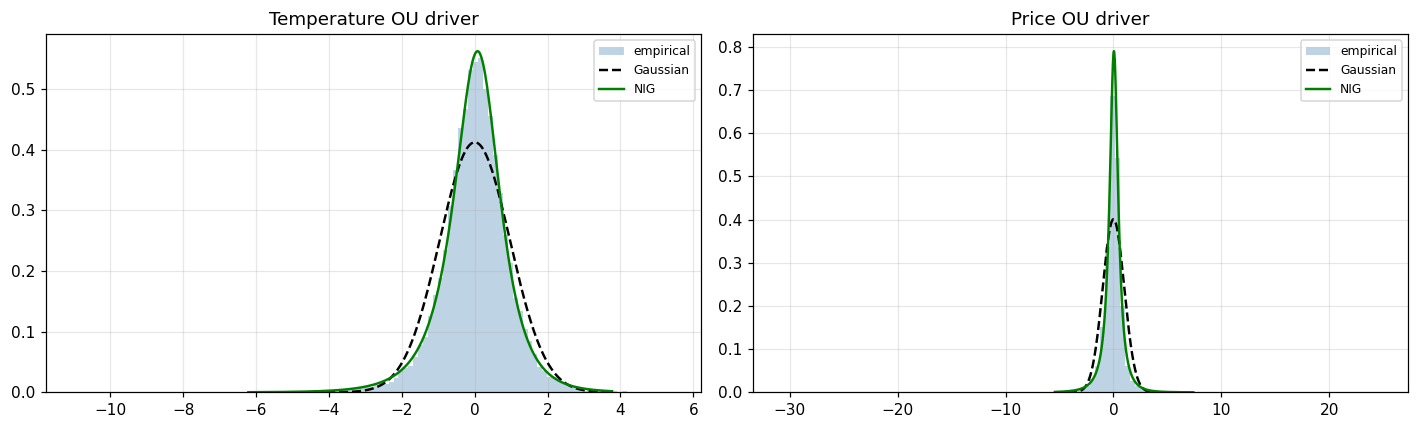

In [5]:
def fitted_params(params_df, series, model):
    sub = params_df[(params_df["series"] == series) & (params_df["model"] == model)]
    return dict(zip(sub["parameter"], sub["value"]))


plot_specs = [
    ("temperature_ou_driver", dL_T, "Temperature OU driver"),
    ("price_ou_driver", dL_X, "Price OU driver"),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (series_name, values, title) in zip(axes, plot_specs):
    values = np.asarray(values, dtype=float)
    x_grid = np.linspace(np.quantile(values, 0.001), np.quantile(values, 0.999), 600)
    g = fitted_params(driver_params, series_name, "Gaussian")
    ax.hist(values, bins=120, density=True, alpha=0.35, color="steelblue", label="empirical")
    ax.plot(x_grid, norm.pdf(x_grid, g["mu"], g["sigma"]), "k--", lw=1.6, label="Gaussian")
    nig = fitted_params(driver_params, series_name, "NIG")
    if nig:
        ax.plot(
            x_grid,
            norminvgauss.pdf(x_grid, nig["scipy_a"], nig["scipy_b"], loc=nig["loc"], scale=nig["scale"]),
            color="green",
            lw=1.6,
            label="NIG",
        )
    ax.set_title(title)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Constant coupling lambda

For the scalar OU states, the residuals are

`R_T(k) = T_k - exp(-kappa_T dt_k) T_{k-1}`,
`R_X(k) = X_k - exp(-kappa_X dt_k) X_{k-1}`.

Under the coupled OU model,

`Cov(R_T, R_X | dt) = lambda * sigma_T^2 *
(1 - exp(-(kappa_T + kappa_X) dt)) / (kappa_T + kappa_X)`.


In [6]:
R_T, dt_obs, F_T_obs, resid_idx = ou_state_residuals(y_T_c, common_idx, kappa_T)
R_X, dt_obs_X, F_X_obs, resid_idx_X = ou_state_residuals(y_X_c, common_idx, kappa_X)
if not np.allclose(dt_obs, dt_obs_X):
    raise RuntimeError("Temperature and price observation intervals are not aligned.")

kernel_TX = ou_cross_kernel(kappa_T, kappa_X, sigma_T, dt_obs)
num_centered = centered_covariance(R_T, R_X)
num_uncentered = float(np.mean(R_T * R_X))
denom_lam = float(np.mean(kernel_TX))
lambda_hat = num_centered / denom_lam
lambda_uncentered = num_uncentered / denom_lam
lambda_centering_difference = lambda_hat - lambda_uncentered
lambda_centering_relative_diff_pct = (
    100.0 * lambda_centering_difference / lambda_hat if lambda_hat != 0 else np.nan
)

var_R_T = float(np.mean((R_T - R_T.mean()) ** 2))
var_R_X = float(np.mean((R_X - R_X.mean()) ** 2))
R2_lam = float(num_centered**2 / (var_R_T * var_R_X))

rng = np.random.default_rng(42)
n_boot = 500
lam_boot = np.empty(n_boot)
for j in range(n_boot):
    idx = rng.integers(0, len(R_T), size=len(R_T))
    rt = R_T[idx]
    rx = R_X[idx]
    kk = kernel_TX[idx]
    lam_boot[j] = centered_covariance(rt, rx) / float(np.mean(kk))

se_lam = float(lam_boot.std(ddof=1))
ci_lam = np.percentile(lam_boot, [2.5, 97.5])
t_stat = float(lambda_hat / se_lam)

lambda_estimate = pd.DataFrame(
    {
        "n_common": [len(R_T)],
        "mean_dt_hours": [float(np.mean(dt_obs))],
        "numerator_centered": [num_centered],
        "numerator_uncentered": [num_uncentered],
        "denominator": [denom_lam],
        "lambda_hat": [lambda_hat],
        "lambda_uncentered": [lambda_uncentered],
        "lambda_centering_difference": [lambda_centering_difference],
        "lambda_centering_relative_diff_pct": [lambda_centering_relative_diff_pct],
        "se": [se_lam],
        "ci_95_lo": [ci_lam[0]],
        "ci_95_hi": [ci_lam[1]],
        "t_stat": [t_stat],
        "R2_output_cross_cov": [R2_lam],
        "mean_R_T": [float(R_T.mean())],
        "mean_R_X": [float(R_X.mean())],
        "std_R_T": [float(np.std(R_T, ddof=1))],
        "std_R_X": [float(np.std(R_X, ddof=1))],
    },
    index=["ou_global"],
)
display(lambda_estimate.round(8))

lambda_estimate.reset_index(names="model").to_csv(LEVY_DIR / "ou_coupling_estimate.csv", index=False)


,n_common,mean_dt_hours,numerator_centered,numerator_uncentered,denominator,lambda_hat,lambda_uncentered,lambda_centering_difference,lambda_centering_relative_diff_pct,se,ci_95_lo,ci_95_hi,t_stat,R2_output_cross_cov,mean_R_T,mean_R_X,std_R_T,std_R_X
ou_global,26280,1.0,-0.000236,-0.000236,0.394472,-0.000597,-0.000597,-1.000000e-08,0.000946,0.000128,-0.00085,-0.000351,-4.659041,0.000893,0.001713,0.000001,0.617255,0.012775


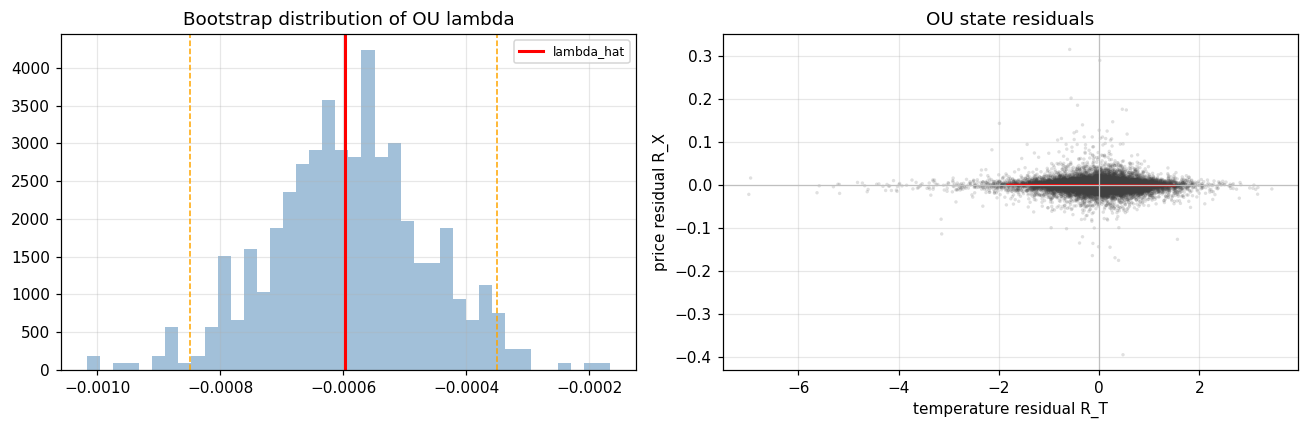

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(lam_boot, bins=40, density=True, color="steelblue", alpha=0.5)
axes[0].axvline(lambda_hat, color="red", lw=2, label="lambda_hat")
axes[0].axvline(ci_lam[0], color="orange", lw=1, ls="--")
axes[0].axvline(ci_lam[1], color="orange", lw=1, ls="--")
axes[0].set_title("Bootstrap distribution of OU lambda")
axes[0].legend(fontsize=8)

axes[1].scatter(R_T, R_X, s=5, alpha=0.16, color="0.25", edgecolors="none", rasterized=True)
if np.std(R_T, ddof=1) > 0:
    slope, intercept = np.polyfit(R_T, R_X, 1)
    xs = np.linspace(np.quantile(R_T, 0.01), np.quantile(R_T, 0.99), 100)
    axes[1].plot(xs, intercept + slope * xs, color="red", lw=1.2)
axes[1].axhline(0, color="0.75", lw=0.8)
axes[1].axvline(0, color="0.75", lw=0.8)
axes[1].set_title("OU state residuals")
axes[1].set_xlabel("temperature residual R_T")
axes[1].set_ylabel("price residual R_X")
plt.tight_layout()
plt.show()


## Price noise scale and driver decomposition

The structural OU price equation is written as

`dX = -kappa_X X dt + lambda sigma_T dL_T + sigma_J dL_J`.

The marginal Yuima OU price scale satisfies approximately
`sigma_X^2 = (lambda sigma_T)^2 + sigma_J^2`.


In [8]:
sigma_J_state = float(np.sqrt(max(sigma_X_marginal**2 - (lambda_hat * sigma_T) ** 2, 0.0)))
temp_variance_share_state_pct = float(
    100.0 * (lambda_hat * sigma_T) ** 2 / sigma_X_marginal**2
    if sigma_X_marginal > 0
    else np.nan
)

driver_cov = centered_covariance(dL_T, dL_X)
driver_slope_marginal = driver_cov / float(np.var(dL_T))
lambda_from_driver_regression = driver_slope_marginal * sigma_X_marginal / sigma_T
driver_resid = dL_X - driver_slope_marginal * dL_T
sigma_J_driver_marginal_units = float(np.std(driver_resid, ddof=1))

price_noise_scale = pd.DataFrame(
    {
        "sigma_T": [sigma_T],
        "sigma_X_marginal": [sigma_X_marginal],
        "lambda_hat": [lambda_hat],
        "lambda_sigma_T": [lambda_hat * sigma_T],
        "sigma_J_state": [sigma_J_state],
        "temp_variance_share_state_pct": [temp_variance_share_state_pct],
        "driver_cov_dLT_dLX": [driver_cov],
        "driver_slope_marginal_units": [driver_slope_marginal],
        "lambda_from_driver_regression": [lambda_from_driver_regression],
        "sigma_J_driver_marginal_units": [sigma_J_driver_marginal_units],
    },
    index=["ou_price_noise"],
)
display(price_noise_scale.round(8))

price_noise_scale.reset_index(names="model").to_csv(LEVY_DIR / "ou_price_noise_scale.csv", index=False)


,sigma_T,sigma_X_marginal,lambda_hat,lambda_sigma_T,sigma_J_state,temp_variance_share_state_pct,driver_cov_dLT_dLX,driver_slope_marginal_units,lambda_from_driver_regression,sigma_J_driver_marginal_units
ou_price_noise,0.64279,0.013345,-0.000597,-0.000384,0.013339,0.082773,-0.028765,-0.030752,-0.000638,0.994719


## Idiosyncratic price driver distribution

For Monte Carlo simulation of the coupled OU model, the price driver should not
double-count the temperature shock. The independent residual driver is estimated
from

`dL_J_hat = (sigma_X dL_X - lambda_hat sigma_T dL_T) / sigma_J`.

The fitted distributions below are therefore for the independent price shock
`dL_J`, not for the marginal price driver `dL_X`.


In [9]:
if sigma_J_state <= 0:
    raise ValueError("sigma_J_state is zero; idiosyncratic price driver cannot be normalized.")

dL_J_s = (
    sigma_X_marginal * dL_X_s
    - lambda_hat * sigma_T * dL_T_s
) / sigma_J_state
dL_J_s.name = "dL_J"
dL_J = dL_J_s.to_numpy(float)

save_increment_series(dL_J_s, LEVY_DIR / "ou_price_idiosyncratic_levy_increments.csv")

idio_fit, idio_params, idio_moments = fit_gaussian_nig(
    dL_J, "price_ou_idiosyncratic_driver"
)
idio_merton_fit, idio_merton_params, idio_jump_mask = fit_merton_threshold(
    dL_J, "price_ou_idiosyncratic_driver"
)

idiosyncratic_driver_fit = pd.concat([idio_fit, idio_merton_fit], ignore_index=True)
idiosyncratic_driver_fit["delta_AIC"] = (
    idiosyncratic_driver_fit["AIC"] - idiosyncratic_driver_fit["AIC"].min()
)
idiosyncratic_driver_params = pd.concat(
    [idio_params, idio_merton_params], ignore_index=True
)
idiosyncratic_driver_moments = pd.DataFrame([idio_moments])

structural_price_shock = lambda_hat * sigma_T * dL_T + sigma_J_state * dL_J
decomposition_check = pd.DataFrame(
    {
        "n": [len(dL_J)],
        "mean_dL_J": [float(np.mean(dL_J))],
        "std_dL_J": [float(np.std(dL_J, ddof=1))],
        "corr_dL_T_dL_J": [safe_pearson_r(dL_T, dL_J)],
        "std_lambda_sigmaT_dLT": [float(np.std(lambda_hat * sigma_T * dL_T, ddof=1))],
        "std_sigmaJ_dLJ": [float(np.std(sigma_J_state * dL_J, ddof=1))],
        "std_reconstructed_price_shock": [float(np.std(structural_price_shock, ddof=1))],
        "std_sigmaX_dLX": [float(np.std(sigma_X_marginal * dL_X, ddof=1))],
        "max_reconstruction_error": [
            float(np.max(np.abs(structural_price_shock - sigma_X_marginal * dL_X)))
        ],
    },
    index=["price_ou_idiosyncratic_driver"],
)

display(idiosyncratic_driver_fit.round(6))
display(
    idiosyncratic_driver_params.pivot_table(
        index=["series", "model"], columns="parameter", values="value", aggfunc="first"
    ).round(6)
)
display(idiosyncratic_driver_moments.round(6))
display(decomposition_check.round(8))

# Keep the global driver CSVs useful for simulation by adding this third driver
# after lambda and sigma_J are known.
driver_fit = driver_fit[driver_fit["series"] != "price_ou_idiosyncratic_driver"]
driver_params = driver_params[driver_params["series"] != "price_ou_idiosyncratic_driver"]
driver_moments = driver_moments[driver_moments["series"] != "price_ou_idiosyncratic_driver"]

driver_fit = pd.concat([driver_fit, idiosyncratic_driver_fit], ignore_index=True)
driver_params = pd.concat([driver_params, idiosyncratic_driver_params], ignore_index=True)
driver_moments = pd.concat([driver_moments, idiosyncratic_driver_moments], ignore_index=True)

driver_fit.to_csv(LEVY_DIR / "ou_levy_driver_fit.csv", index=False)
driver_params.to_csv(LEVY_DIR / "ou_levy_driver_params.csv", index=False)
driver_moments.to_csv(LEVY_DIR / "ou_levy_driver_moments.csv", index=False)

idiosyncratic_driver_fit.to_csv(
    LEVY_DIR / "ou_price_idiosyncratic_driver_fit.csv", index=False
)
idiosyncratic_driver_params.to_csv(
    LEVY_DIR / "ou_price_idiosyncratic_driver_params.csv", index=False
)
idiosyncratic_driver_moments.to_csv(
    LEVY_DIR / "ou_price_idiosyncratic_driver_moments.csv", index=False
)
decomposition_check.to_csv(
    LEVY_DIR / "ou_price_idiosyncratic_decomposition_check.csv"
)


,series,model,loglik,n_params,AIC,BIC,delta_AIC
0,price_ou_idiosyncratic_driver,Gaussian,-37160.974079,2,74325.948158,74342.301285,14300.118533
1,price_ou_idiosyncratic_driver,NIG,-30008.914812,4,60025.829625,60058.535879,0.000000
2,price_ou_idiosyncratic_driver,Merton_threshold,-30764.513357,4,61537.026714,61569.732968,1511.197089


parameter                                          alpha      beta     delta  \
series                        model                                            
price_ou_idiosyncratic_driver Gaussian               NaN       NaN       NaN   
                              Merton_threshold       NaN       NaN       NaN   
                              NIG               0.596535 -0.055667  0.496581   

parameter                                       jump_intensity  jump_mean  \
series                        model                                         
price_ou_idiosyncratic_driver Gaussian                     NaN        NaN   
                              Merton_threshold         0.05742  -0.017352   
                              NIG                          NaN        NaN   

parameter                                       jump_sigma  jump_threshold  \
series                        model                                          
price_ou_idiosyncratic_driver Gaussian                 NaN             NaN   
                              Merton_threshold    3.400854        1.696614   
                              NIG                      NaN             NaN   

parameter                                            loc        mu  n_jumps  \
series                        model                                           
price_ou_idiosyncratic_driver Gaussian               NaN  0.000179      NaN   
                              Merton_threshold       NaN       NaN   1509.0   
                              NIG               0.046749  0.046749      NaN   

parameter                                          scale   scipy_a   scipy_b  \
series                        model                                            
price_ou_idiosyncratic_driver Gaussian               NaN       NaN       NaN   
                              Merton_threshold       NaN       NaN       NaN   
                              NIG               0.496581  0.296228 -0.027643   

parameter                                          sigma  sigma_diffusion  
series                        model                                        
price_ou_idiosyncratic_driver Gaussian          0.995114              NaN  
                              Merton_threshold       NaN         0.588617  
                              NIG                    NaN              NaN

,series,n,mean,std,skew,kurtosis
0,price_ou_idiosyncratic_driver,26280,0.000179,0.995132,0.42355,84.882218


,n,mean_dL_J,std_dL_J,corr_dL_T_dL_J,std_lambda_sigmaT_dLT,std_sigmaJ_dLJ,std_reconstructed_price_shock,std_sigmaX_dLX,max_reconstruction_error
price_ou_idiosyncratic_driver,26280,0.000179,0.995132,-0.001927,0.000371,0.013274,0.01328,0.01328,0.0


## Joint OU validation

With observed scalar OU states, the one-step innovations are the state residuals.
The model covariance for each interval is checked directly against the empirical
innovation covariance.


In [10]:
Q_T = ou_variance_kernel(kappa_T, sigma_T, dt_obs)
Q_X = ou_variance_kernel(kappa_X, sigma_X_marginal, dt_obs)
Q_TX = lambda_hat * kernel_TX

model_corr = Q_TX / np.sqrt(Q_T * Q_X)
joint_innovation_covariance = pd.DataFrame(
    {
        "n": [len(R_T)],
        "mean_v_T": [float(R_T.mean())],
        "mean_v_X": [float(R_X.mean())],
        "empirical_E_vT_vX": [float(np.mean(R_T * R_X))],
        "empirical_centered_cov_v": [centered_covariance(R_T, R_X)],
        "mean_model_S_TX": [float(np.mean(Q_TX))],
        "raw_cov_error": [float(np.mean(R_T * R_X) - np.mean(Q_TX))],
        "centered_cov_error": [float(centered_covariance(R_T, R_X) - np.mean(Q_TX))],
        "empirical_corr_v": [safe_pearson_r(R_T, R_X)],
        "empirical_spearman_v": [safe_spearman_r(R_T, R_X)],
        "mean_model_corr": [float(np.mean(model_corr))],
    },
    index=["ou_constant_lambda"],
)
display(joint_innovation_covariance.round(8))

joint_innovation_covariance.reset_index(names="model").to_csv(
    LEVY_DIR / "ou_lambda_innovation_covariance.csv", index=False
)


,n,mean_v_T,mean_v_X,empirical_E_vT_vX,empirical_centered_cov_v,mean_model_S_TX,raw_cov_error,centered_cov_error,empirical_corr_v,empirical_spearman_v,mean_model_corr
ou_constant_lambda,26280,0.001713,0.000001,-0.000236,-0.000236,-0.000236,0.0,0.0,-0.02988,-0.044551,-0.028765


In [11]:
S_mats = np.zeros((len(R_T), 2, 2))
S_mats[:, 0, 0] = Q_T
S_mats[:, 1, 1] = Q_X
S_mats[:, 0, 1] = Q_TX
S_mats[:, 1, 0] = Q_TX
V = np.column_stack([R_T, R_X])

joint_loglik = 0.0
for v, S in zip(V, S_mats):
    sign, logdet = np.linalg.slogdet(S)
    if sign <= 0:
        logdet = np.log(max(np.linalg.det(S), 1e-300))
    joint_loglik += -0.5 * (2 * np.log(2 * np.pi) + logdet + v @ np.linalg.solve(S, v))
joint_loglik = float(joint_loglik)

y_pred_X = F_X_obs * y_X_c[:-1]
err_X = y_X_c[1:] - y_pred_X
rmse = float(np.sqrt(np.mean(err_X**2)))
mae = float(np.mean(np.abs(err_X)))
ss_res = float(np.sum(err_X**2))
ss_tot = float(np.sum((y_X_c[1:] - y_X_c[1:].mean()) ** 2))
r2_price = float(1.0 - ss_res / ss_tot)

z_X = R_X / np.sqrt(Q_X)
lb = acorr_ljungbox(z_X, lags=[24, 48, 168], return_df=True)
price_validation = pd.DataFrame(
    {
        "RMSE": [rmse],
        "MAE": [mae],
        "R2": [r2_price],
        "joint_loglik": [joint_loglik],
        "joint_AIC_6_params": [-2.0 * joint_loglik + 2.0 * 6],
        "mean_z_X": [float(z_X.mean())],
        "std_z_X": [float(z_X.std(ddof=1))],
        "skew_z_X": [float(pd.Series(z_X).skew())],
        "kurtosis_z_X": [float(pd.Series(z_X).kurtosis() + 3)],
        "LB_pvalue_24": [float(lb.loc[24, "lb_pvalue"])],
        "LB_pvalue_48": [float(lb.loc[48, "lb_pvalue"])],
        "LB_pvalue_168": [float(lb.loc[168, "lb_pvalue"])],
    },
    index=["ou_constant_lambda"],
)
display(price_validation.round(8))

price_validation.reset_index(names="model").to_csv(LEVY_DIR / "ou_lambda_price_validation.csv", index=False)


,RMSE,MAE,R2,joint_loglik,joint_AIC_6_params,mean_z_X,std_z_X,skew_z_X,kurtosis_z_X,LB_pvalue_24,LB_pvalue_48,LB_pvalue_168
ou_constant_lambda,0.012775,0.007582,0.855312,52670.655575,-105329.311149,0.000101,0.995402,0.427647,84.929194,0.0,0.0,0.0


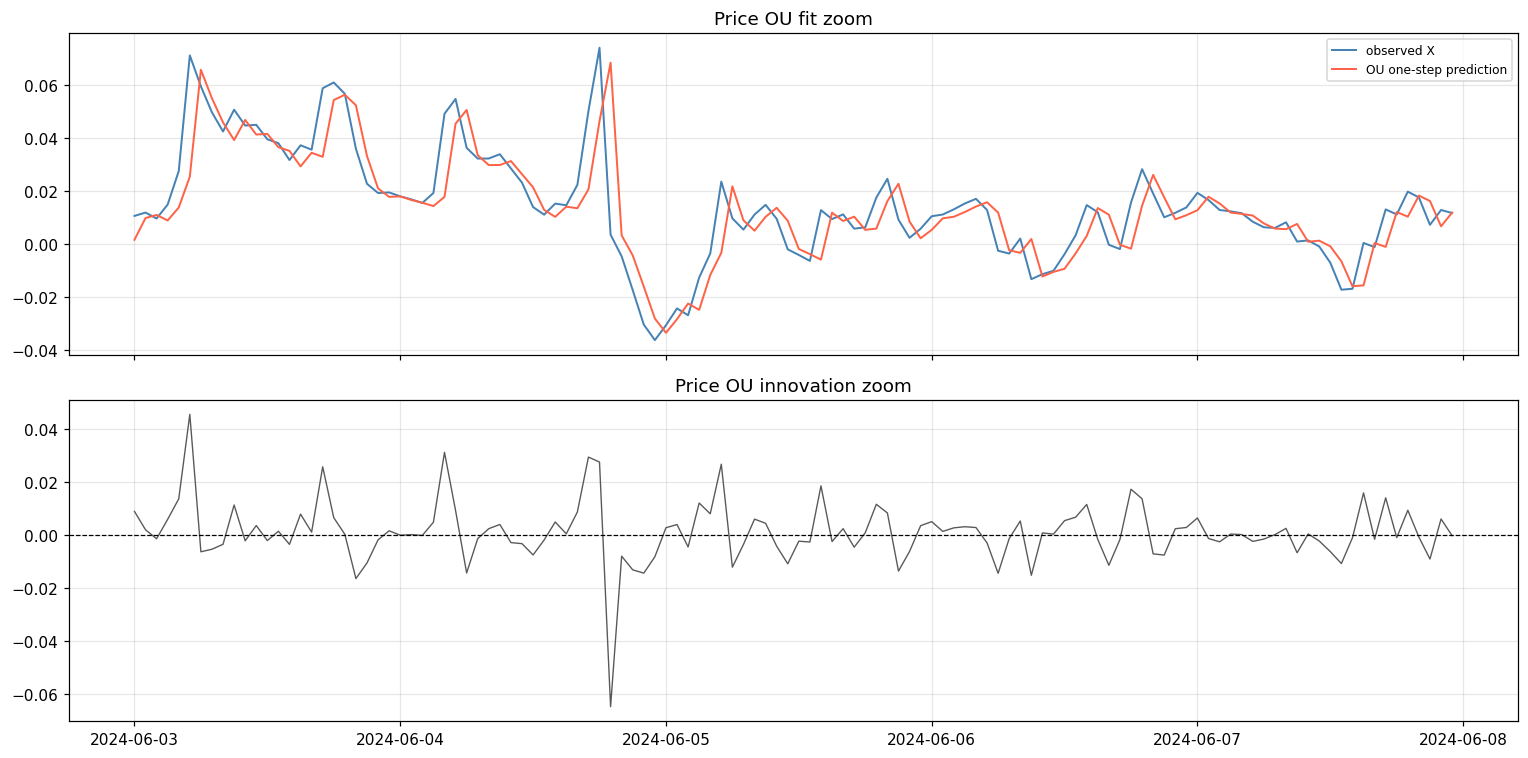

In [12]:
time_resid = resid_idx
mask = (time_resid >= pd.Timestamp("2024-06-03", tz="UTC")) & (
    time_resid < pd.Timestamp("2024-06-08", tz="UTC")
)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(time_resid[mask], y_X_c[1:][mask], lw=1.3, color="steelblue", label="observed X")
axes[0].plot(time_resid[mask], y_pred_X[mask], lw=1.3, color="tomato", label="OU one-step prediction")
axes[0].set_title("Price OU fit zoom")
axes[0].legend(fontsize=8)

axes[1].plot(time_resid[mask], R_X[mask], lw=0.9, color="0.35")
axes[1].axhline(0, color="black", ls="--", lw=0.8)
axes[1].set_title("Price OU innovation zoom")
plt.tight_layout()
plt.show()


## Monte Carlo simulation parameters


In [13]:
def get_param(params_df, series, model, parameter):
    row = params_df[
        (params_df["series"] == series)
        & (params_df["model"] == model)
        & (params_df["parameter"] == parameter)
    ]
    if row.empty:
        raise KeyError((series, model, parameter))
    return float(row["value"].iloc[0])


temp_series = "temperature_ou_driver"
idio_series = "price_ou_idiosyncratic_driver"

mc_final_parameters = pd.DataFrame([
    {"component": "global", "parameter": "model_family", "value": "coupled_OU"},
    {"component": "global", "parameter": "dt_hours", "value": 1.0},

    {"component": "temperature_state", "parameter": "kappa_T", "value": kappa_T},
    {"component": "temperature_state", "parameter": "b_T", "value": b_T},
    {"component": "temperature_state", "parameter": "sigma_T", "value": sigma_T},

    {"component": "temperature_driver", "parameter": "distribution", "value": "Gaussian"},
    {"component": "temperature_driver", "parameter": "mu", "value": get_param(driver_params, temp_series, "Gaussian", "mu")},
    {"component": "temperature_driver", "parameter": "sigma", "value": get_param(driver_params, temp_series, "Gaussian", "sigma")},

    {"component": "price_state", "parameter": "kappa_X", "value": kappa_X},
    {"component": "price_state", "parameter": "b_X", "value": b_X},
    {"component": "price_state", "parameter": "lambda", "value": lambda_hat},
    {"component": "price_state", "parameter": "lambda_sigma_T", "value": lambda_hat * sigma_T},
    {"component": "price_state", "parameter": "sigma_J", "value": sigma_J_state},

    {"component": "price_idiosyncratic_driver", "parameter": "distribution", "value": "NIG"},
    {"component": "price_idiosyncratic_driver", "parameter": "alpha", "value": get_param(driver_params, idio_series, "NIG", "alpha")},
    {"component": "price_idiosyncratic_driver", "parameter": "beta", "value": get_param(driver_params, idio_series, "NIG", "beta")},
    {"component": "price_idiosyncratic_driver", "parameter": "delta", "value": get_param(driver_params, idio_series, "NIG", "delta")},
    {"component": "price_idiosyncratic_driver", "parameter": "mu", "value": get_param(driver_params, idio_series, "NIG", "mu")},
])

display(mc_final_parameters)
mc_final_parameters.to_csv(LEVY_DIR / "ou_montecarlo_final_parameters.csv", index=False)
mc_final_parameters.to_csv(LEVY_DIR / "ou_montecarlo_driver_params.csv", index=False)


,component,parameter,value
0,global,model_family,coupled_OU
1,global,dt_hours,1.0
2,temperature_state,kappa_T,0.014377
3,temperature_state,b_T,1.0
4,temperature_state,sigma_T,0.64279
5,temperature_driver,distribution,Gaussian
6,temperature_driver,mu,0.002684
7,temperature_driver,sigma,0.967159
8,price_state,kappa_X,0.079015
9,price_state,b_X,1.0
